# Task 1: Load and Data Analysis

In [1]:
# loading a dataset from openml
import pandas as pd
from sklearn.datasets import fetch_openml
boston = fetch_openml(data_id=531)

In [3]:
df = pd.DataFrame(data=boston.data, columns=boston.feature_names)
df['target'] = boston.target
df = df.drop(['CHAS', 'RAD'], axis=1)
display(df.head())

,CRIM,ZN,INDUS,NOX,RM,AGE,DIS,TAX,PTRATIO,B,LSTAT,target
0,0.00632,18.0,2.31,0.538,6.575,65.2,4.0900,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.469,6.421,78.9,4.9671,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.469,7.185,61.1,4.9671,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.458,6.998,45.8,6.0622,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.458,7.147,54.2,6.0622,222.0,18.7,396.90,5.33,36.2


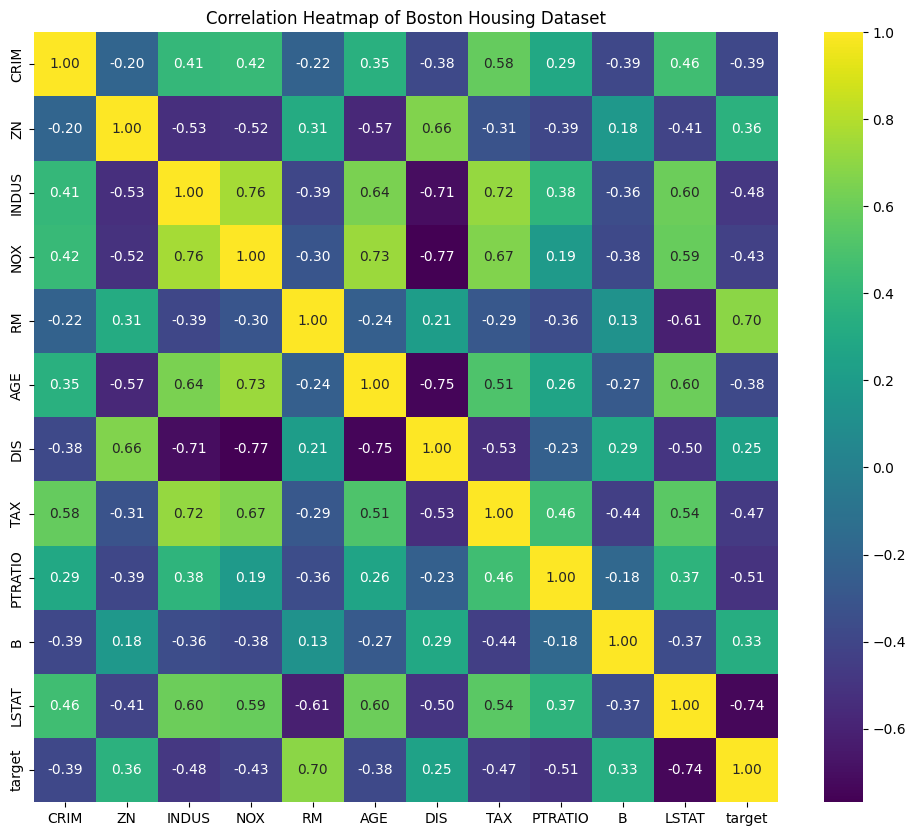

In [ ]:
# Heatmap
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='viridis', fmt=".2f")
plt.title('Correlation Heatmap of Boston Housing Dataset')
plt.show()

In [2]:
import numpy as np

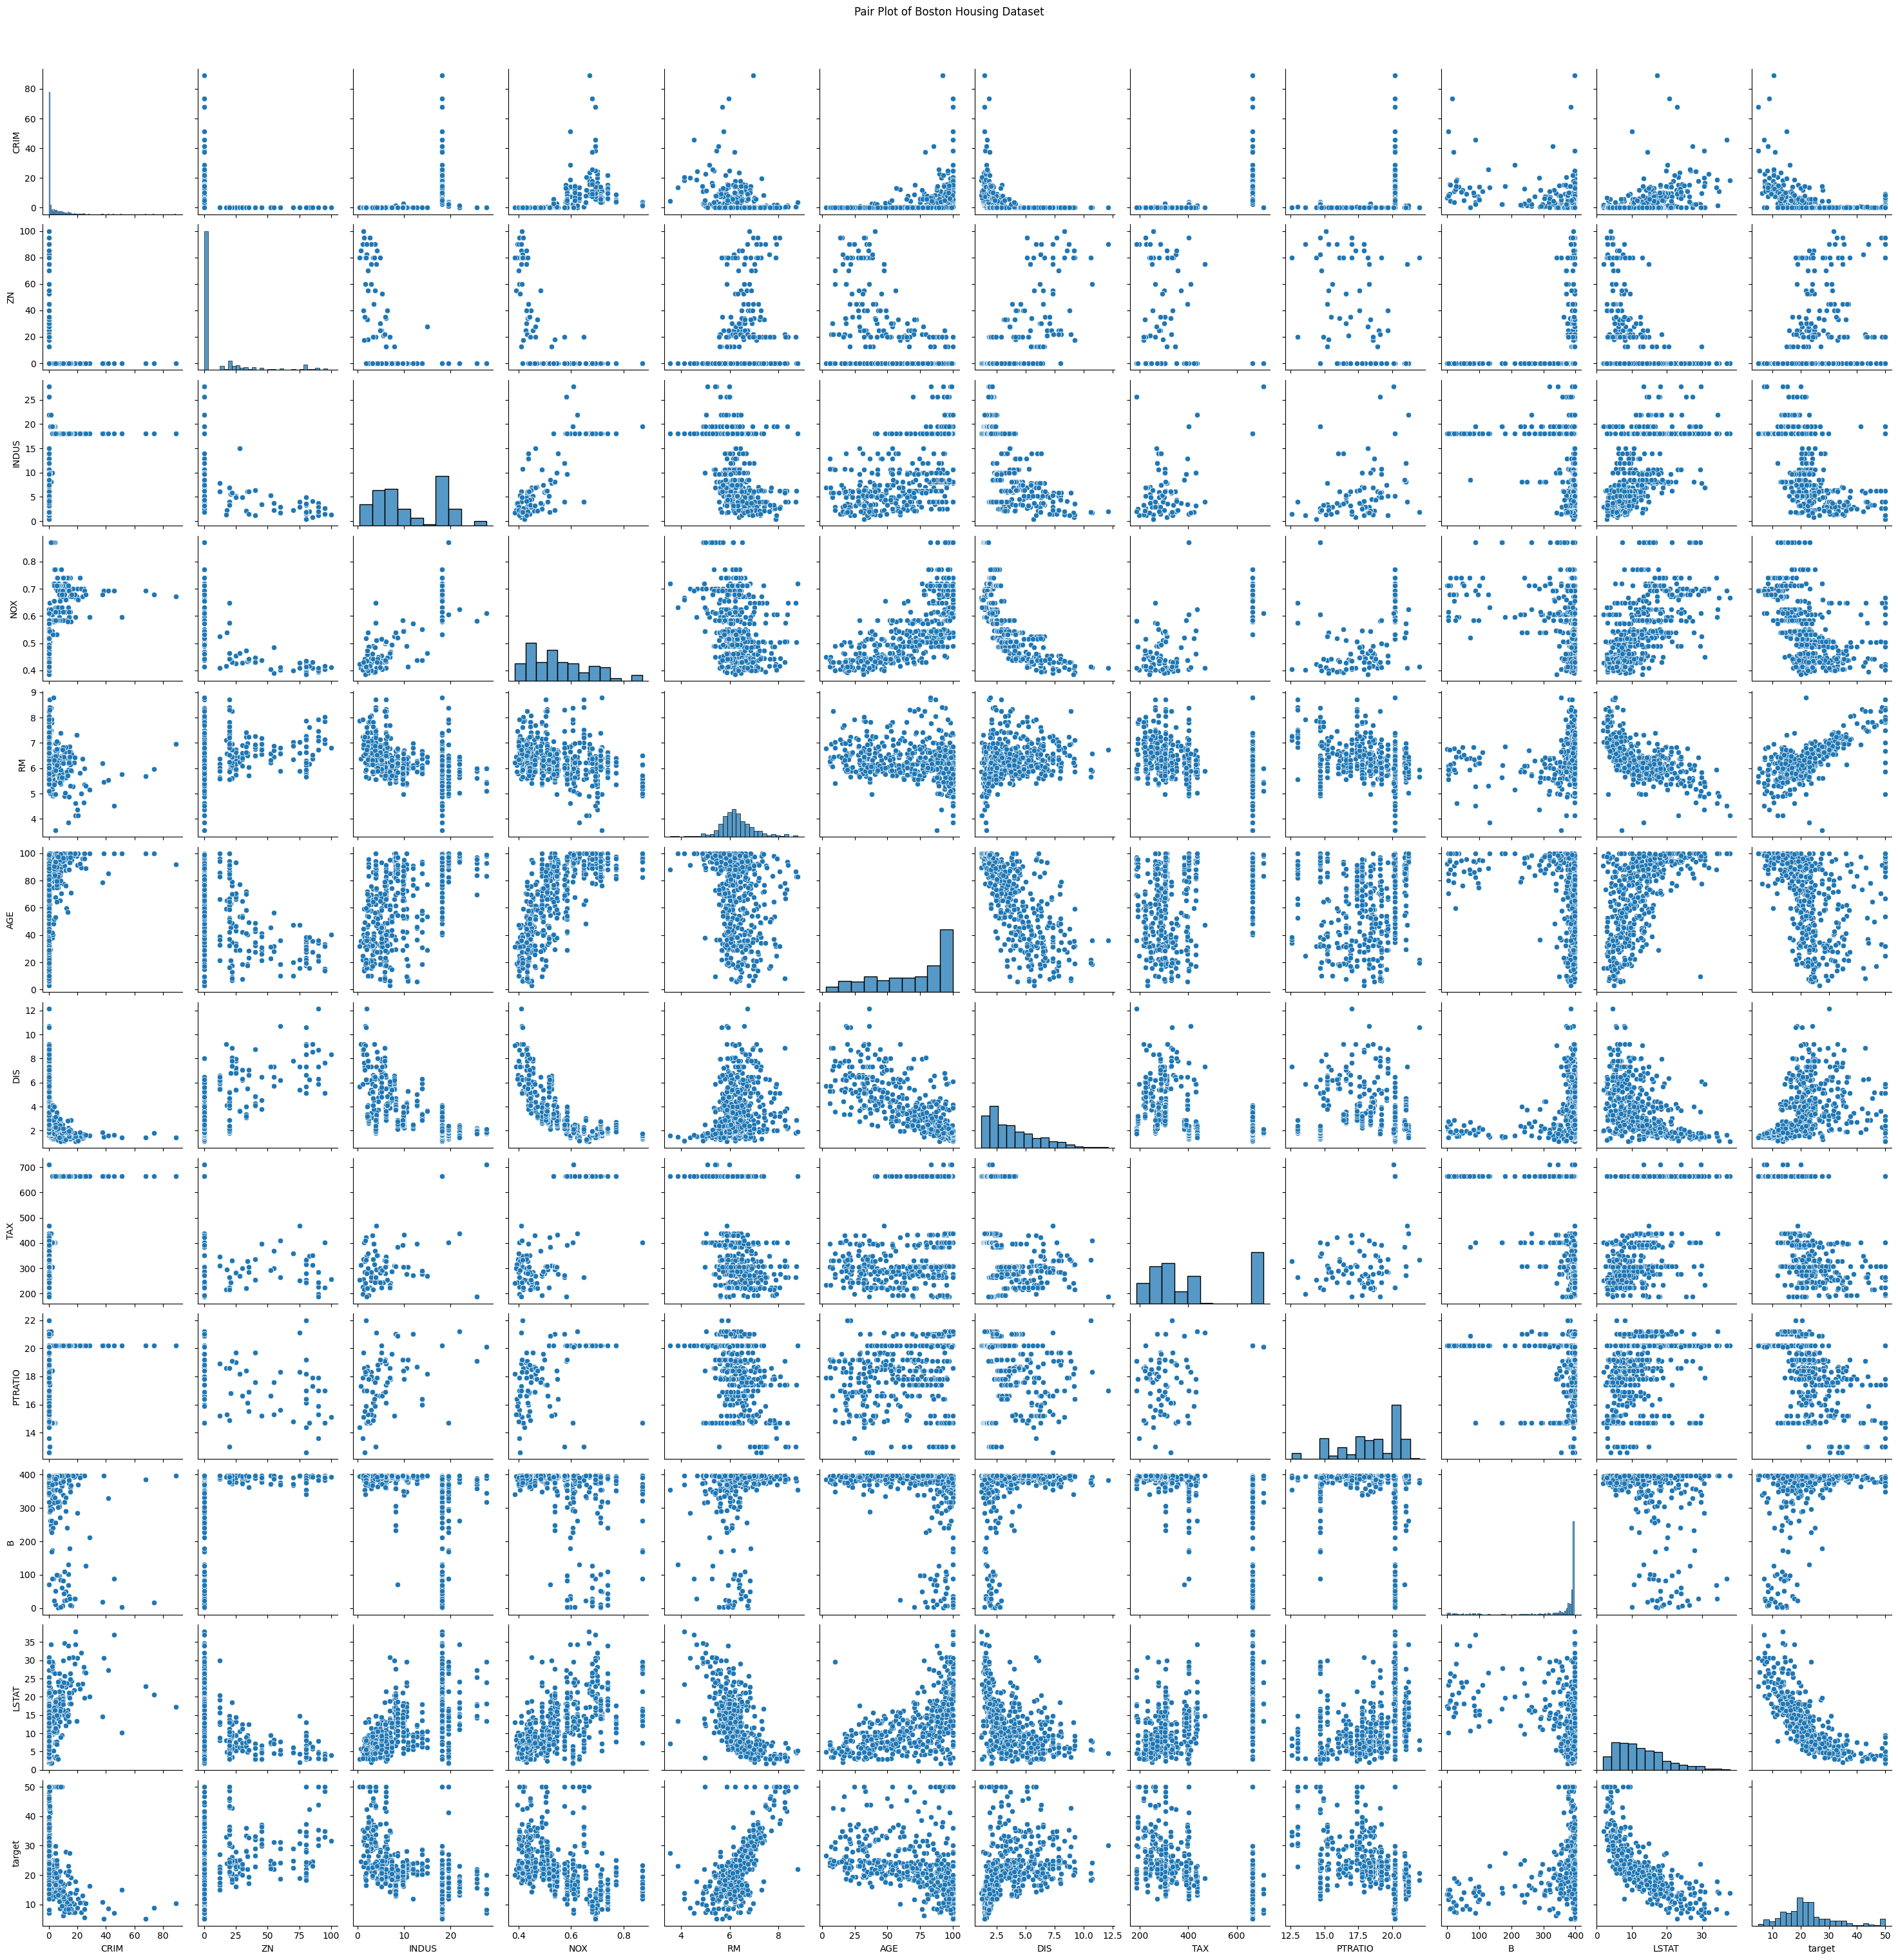

In [ ]:
import seaborn as sns
# Pair plot
sns.pairplot(df)
plt.suptitle('Pair Plot of Boston Housing Dataset', y=1.02)
plt.show()

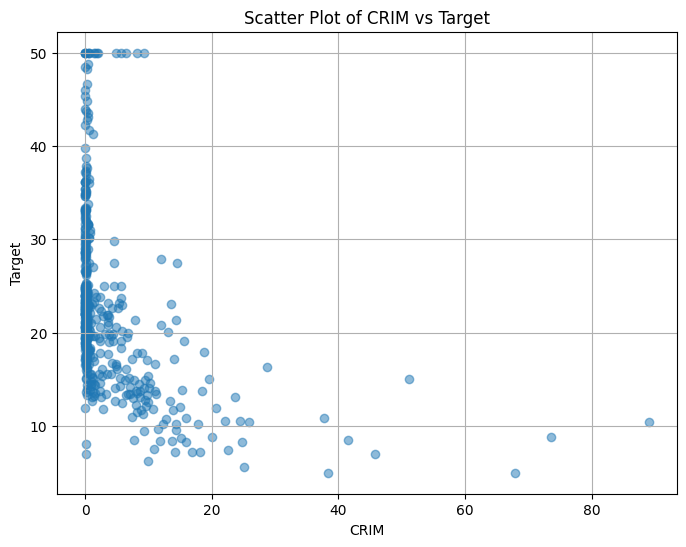

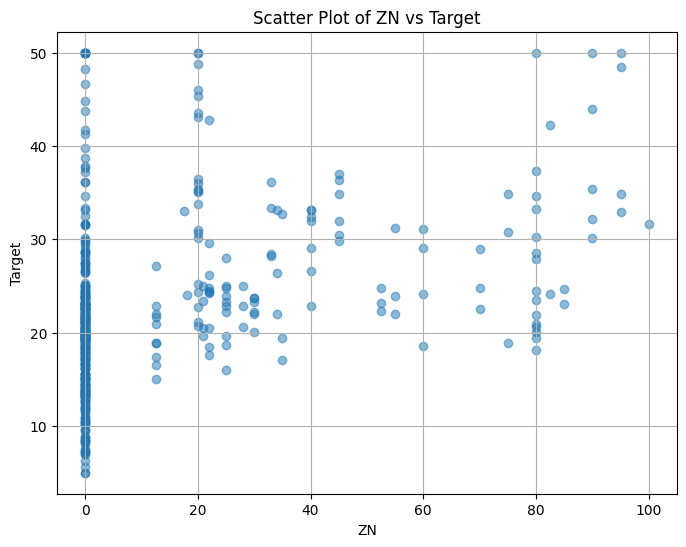

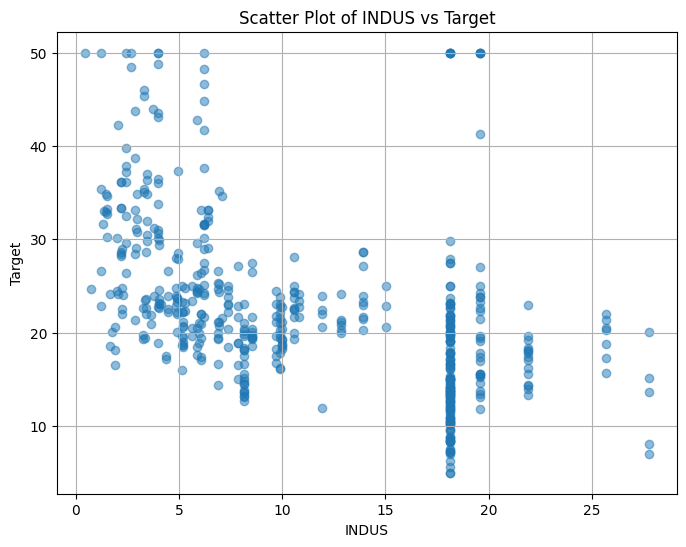

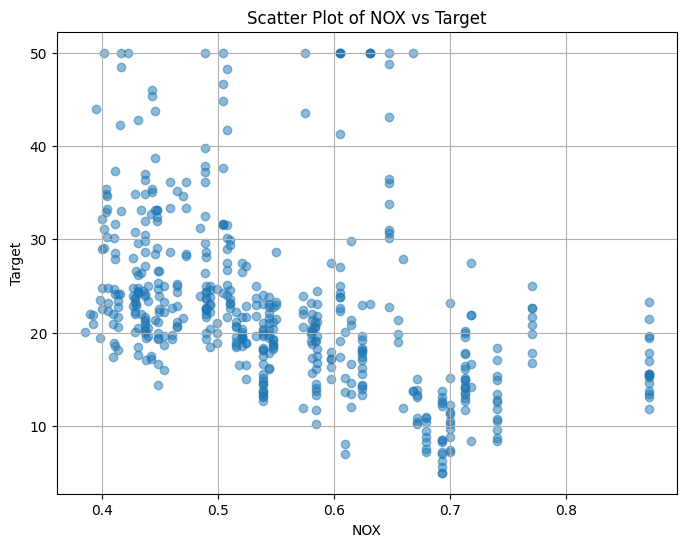

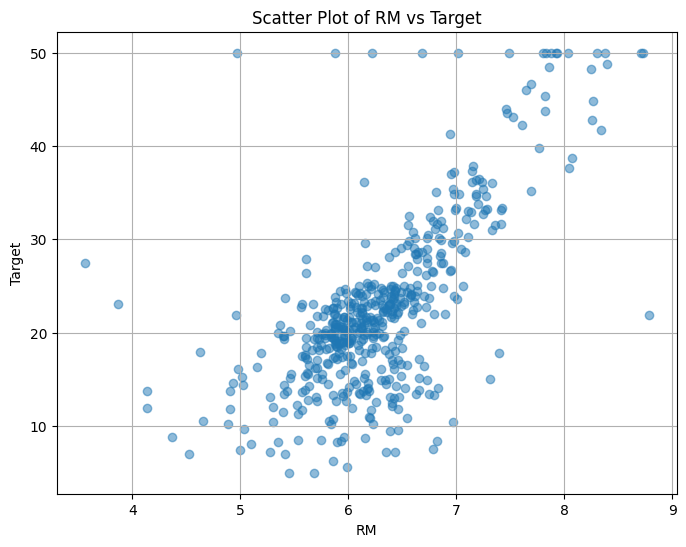

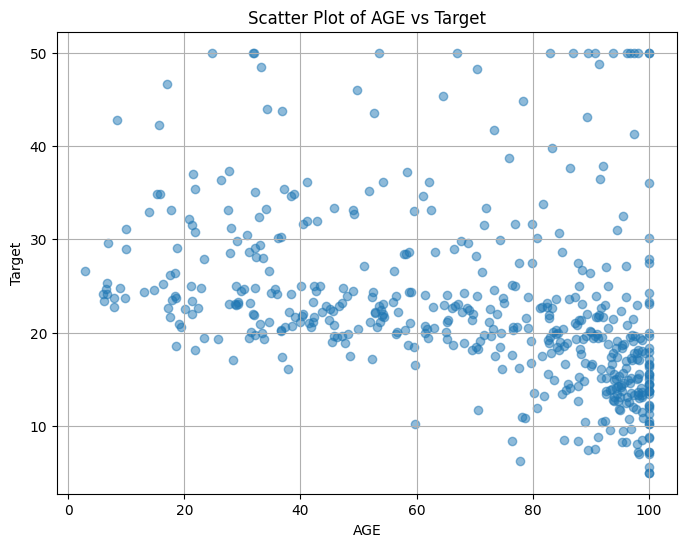

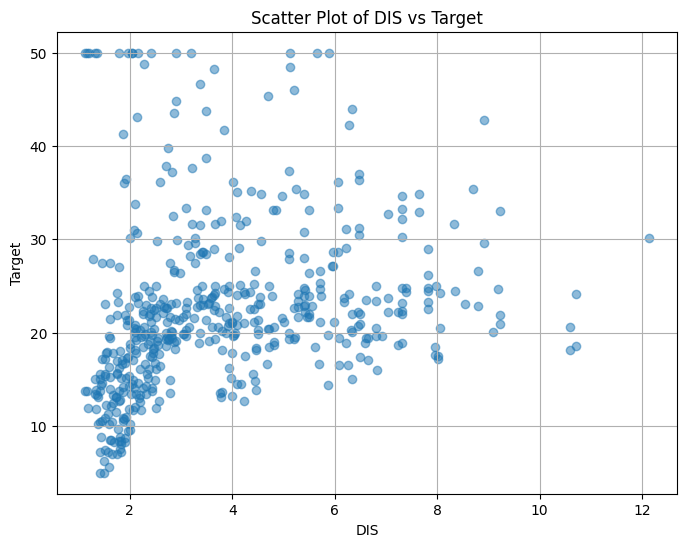

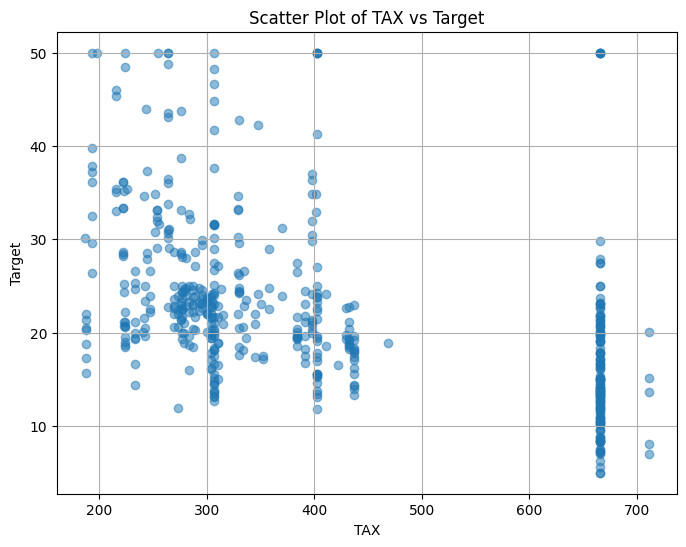

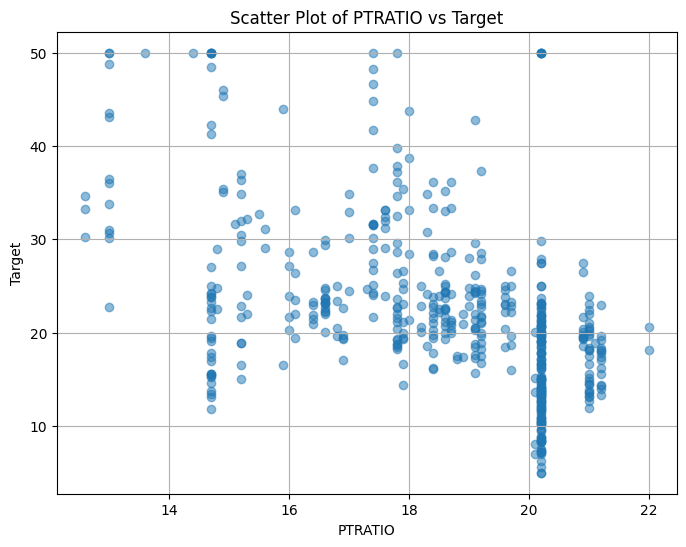

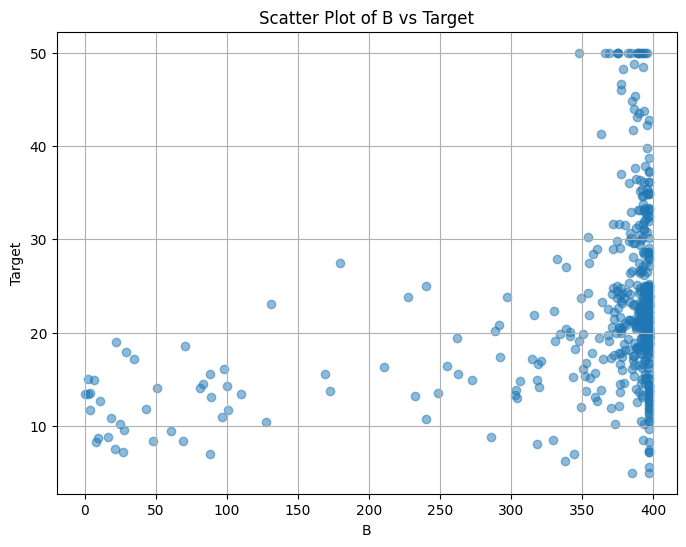

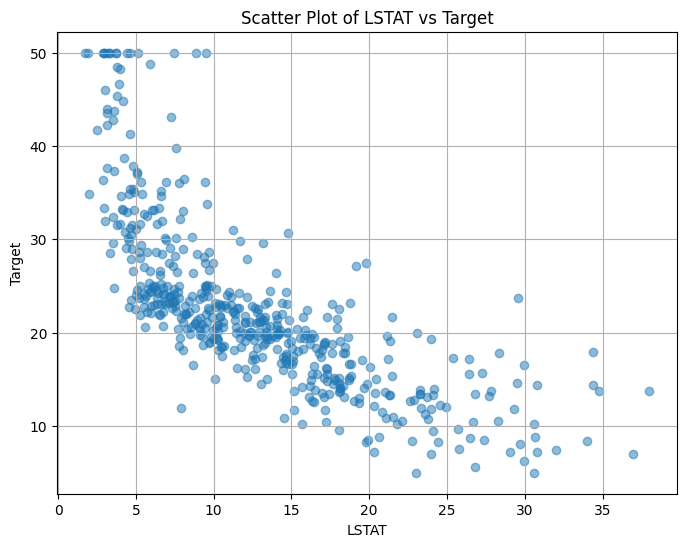

In [ ]:
# Scatter plots
for feature in df.columns:
  if feature != 'target':
    plt.figure(figsize=(8, 6))
    plt.scatter(df[feature], df['target'], alpha=0.5)
    plt.title(f'Scatter Plot of {feature} vs Target')
    plt.xlabel(feature)
    plt.ylabel('Target')
    plt.grid(True)
    plt.show()

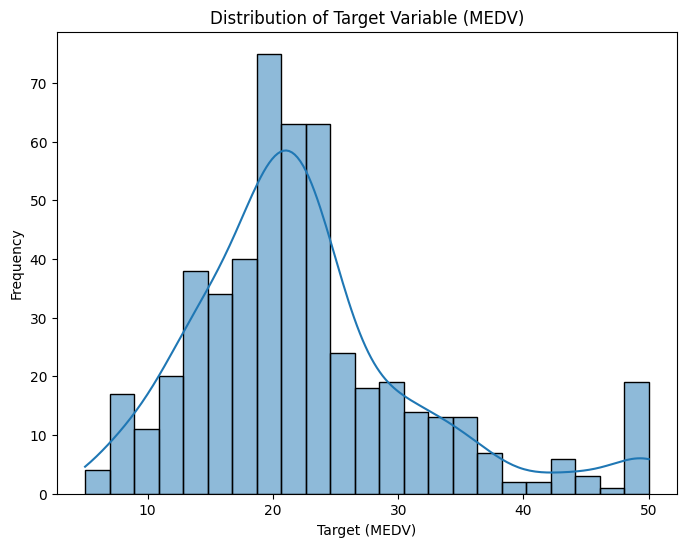

In [ ]:
# Distribution of target (MEDV)
plt.figure(figsize=(8, 6))
sns.histplot(df['target'], kde=True)
plt.title('Distribution of Target Variable (MEDV)')
plt.xlabel('Target (MEDV)')
plt.ylabel('Frequency')
plt.show()

# Task 2: Scaling and Splitting the data

In [4]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns, index=df.index)

display(df_scaled.head())

,CRIM,ZN,INDUS,NOX,RM,AGE,DIS,TAX,PTRATIO,B,LSTAT,target
0,0.000000,0.18,0.067815,0.314815,0.577505,0.641607,0.269203,0.208015,0.287234,1.000000,0.089680,0.422222
1,0.000236,0.00,0.242302,0.172840,0.547998,0.782698,0.348962,0.104962,0.553191,1.000000,0.204470,0.368889
2,0.000236,0.00,0.242302,0.172840,0.694386,0.599382,0.348962,0.104962,0.553191,0.989737,0.063466,0.660000
3,0.000293,0.00,0.063050,0.150206,0.658555,0.441813,0.448545,0.066794,0.648936,0.994276,0.033389,0.631111
4,0.000705,0.00,0.063050,0.150206,0.687105,0.528321,0.448545,0.066794,0.648936,1.000000,0.099338,0.693333


In [5]:
from sklearn.model_selection import train_test_split

# Splitting the dataset into training and testing
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Task 3: Implementing KNN Regressor from Scratch

In [6]:
def manhattan_distance(x, y):
    return np.sum(np.abs(x - y))

def euclidean_distance(x, y):
    return np.sqrt(np.sum((x - y)**2))

def cosine_distance(x, y):
    return 1 - np.dot(x, y) / (np.linalg.norm(x) * np.linalg.norm(y))


class KNNRegressor:
    def __init__(self, k=5, distance_metric='euclidean'):
        self.k = k
        self.distance_metric = distance_metric

    def fit(self, X_train, y_train):
        self.X_train = X_train.values
        self.y_train = y_train.values

    def _compute_distance(self, x):
        if self.distance_metric == 'euclidean':
            distances = [euclidean_distance(x, x_train) for x_train in self.X_train]
        elif self.distance_metric == 'manhattan':
             distances = [manhattan_distance(x, x_train) for x_train in self.X_train]
        elif self.distance_metric == 'cosine':
            distances = [cosine_distance(x, x_train) for x_train in self.X_train]
        else:
            raise ValueError("Unsupported distance metric")
        return distances

    def predict(self, X_test):
        X_test = X_test.values
        predictions = []
        for x in X_test:
            distances = self._compute_distance(x)
            nearest_indices = np.argsort(distances)[:self.k]
            nearest_targets = self.y_train[nearest_indices]
            prediction = np.mean(nearest_targets)
            predictions.append(prediction)
        return np.array(predictions)

In [8]:
k_values = [3, 5, 7, 9, 11]
distance_metrics = ['euclidean', 'manhattan', 'cosine']

results = []

In [11]:
from sklearn.metrics import r2_score
from sklearn.neighbors import KNeighborsRegressor

# Evaluating our custom KNN regressor model alongside Scikit-learn's
# KNeighborsRegressor with algorithm='brute', weights='uniform', and
# the same (k, distance metric) to train and test on the dataset.

results = []
skl_results = []

for k in k_values:
    for metric in distance_metrics:
        print(f"Evaluating Custom KNN and Scikit-learns's KNN with k={k} and distance metric='{metric}'")
        model = KNNRegressor(k=k, distance_metric=metric)
        model.fit(X_train, y_train)
        predictions = model.predict(X_test)
        r2 = r2_score(y_test, predictions)
        results.append({'k': k, 'distance_metric': metric, 'r2_score': r2})
        print(f"Custom R² score: {r2:.4f}")

        skl_model = KNeighborsRegressor(n_neighbors=k, metric=metric, algorithm='brute', weights='uniform')
        skl_model.fit(X_train, y_train)
        skl_predictions = skl_model.predict(X_test)
        skl_r2 = r2_score(y_test, skl_predictions)
        skl_results.append({'k': k, 'distance_metric': metric, 'r2_score': skl_r2})
        print(f"Scikit-learn R² score: {skl_r2:.4f}\n")

Evaluating Custom KNN and Scikit-learns's KNN with k=3 and distance metric='euclidean'
Custom R² score: 0.6969
Scikit-learn R² score: 0.6969

Evaluating Custom KNN and Scikit-learns's KNN with k=3 and distance metric='manhattan'
Custom R² score: 0.7104
Scikit-learn R² score: 0.7104

Evaluating Custom KNN and Scikit-learns's KNN with k=3 and distance metric='cosine'
Custom R² score: 0.6448
Scikit-learn R² score: 0.6448

Evaluating Custom KNN and Scikit-learns's KNN with k=5 and distance metric='euclidean'
Custom R² score: 0.6419
Scikit-learn R² score: 0.6419

Evaluating Custom KNN and Scikit-learns's KNN with k=5 and distance metric='manhattan'
Custom R² score: 0.6936
Scikit-learn R² score: 0.6936

Evaluating Custom KNN and Scikit-learns's KNN with k=5 and distance metric='cosine'
Custom R² score: 0.6519
Scikit-learn R² score: 0.6519

Evaluating Custom KNN and Scikit-learns's KNN with k=7 and distance metric='euclidean'
Custom R² score: 0.5895
Scikit-learn R² score: 0.5895

Evaluating C

In [12]:
# Table summarizing the R² scores for each (k, distance metric)
# for both custom and Scikit-learn's model

results_df = pd.DataFrame(results)
skl_results_df = pd.DataFrame(skl_results)

print("Custom KNN Regressor Results:")
display(results_df)

print("\nScikit-learn KNeighborsRegressor Results:")
display(skl_results_df)

Custom KNN Regressor Results:


,k,distance_metric,r2_score
0,3,euclidean,0.696891
1,3,manhattan,0.710421
2,3,cosine,0.644792
3,5,euclidean,0.641940
4,5,manhattan,0.693615
5,5,cosine,0.651917
6,7,euclidean,0.589473
7,7,manhattan,0.642344
8,7,cosine,0.602494
9,9,euclidean,0.523658



Scikit-learn KNeighborsRegressor Results:


,k,distance_metric,r2_score
0,3,euclidean,0.696891
1,3,manhattan,0.710421
2,3,cosine,0.644792
3,5,euclidean,0.641940
4,5,manhattan,0.693615
5,5,cosine,0.651917
6,7,euclidean,0.589473
7,7,manhattan,0.642344
8,7,cosine,0.602494
9,9,euclidean,0.523658


# Task 4: Comparing with scikit-learn's Simple KNN

In [13]:
# Identifying the best R2 score
best_row = results_df.loc[results_df['r2_score'].idxmax()]
best_k = int(best_row['k'])
best_metric = best_row['distance_metric']

print(f"Best k: {best_k}")
print(f"Best distance metric: {best_metric}")

Best k: 3
Best distance metric: manhattan


In [14]:
from sklearn.neighbors import KNeighborsRegressor
# finding the best R2 score for scikit-learn's model
skl_model = KNeighborsRegressor(n_neighbors=best_k, metric=best_metric, algorithm='brute', weights='uniform')
skl_model.fit(X_train, y_train)
skl_predictions = skl_model.predict(X_test)
skl_r2_score = r2_score(y_test, skl_predictions)

print(f"Scikit-learn best R² score: {skl_r2_score:.4f}")

Scikit-learn best R² score: 0.7104


In [15]:
custom_r2_score = best_row['r2_score']

print(f"Scikit-learn R² score: {skl_r2_score:.4f}")
print(f"Custom KNN Regressor R² score (best combination): {custom_r2_score:.4f}")

if abs(skl_r2_score - custom_r2_score) < 1e-6:
    print("\nThe R² scores of the scikit-learn and custom models are very similar.")
else:
    print("\nThe R² scores of the scikit-learn and custom models are different.")

Scikit-learn R² score: 0.7104
Custom KNN Regressor R² score (best combination): 0.7104

The R² scores of the scikit-learn and custom models are very similar.


# Task 5: Implement Weighted KNN Regressor from Scratch

In [16]:
class WeightedKNNRegressor:
    def __init__(self, k=5, distance_metric='euclidean'):
        self.k = k
        self.distance_metric = distance_metric

    def fit(self, X_train, y_train):
        self.X_train = X_train.values
        self.y_train = y_train.values

    def _compute_distance(self, x):
        if self.distance_metric == 'euclidean':
            distances = [euclidean_distance(x, x_train) for x_train in self.X_train]
        elif self.distance_metric == 'manhattan':
             distances = [manhattan_distance(x, x_train) for x_train in self.X_train]
        elif self.distance_metric == 'cosine':
            distances = [cosine_distance(x, x_train) for x_train in self.X_train]
        else:
            raise ValueError("Unsupported distance metric")
        return distances

    def predict(self, X_test):
        X_test = X_test.values
        predictions = []
        for x in X_test:
            distances = self._compute_distance(x)
            nearest_indices = np.argsort(distances)[:self.k]
            nearest_targets = self.y_train[nearest_indices]
            nearest_distances = np.array(distances)[nearest_indices]
            # Calculated weights (inverse of distance, with epsilon for zero distance)
            weights = 1 / (nearest_distances + 1e-6)
            # Calculated weighted average
            weighted_average = np.sum(nearest_targets * weights) / np.sum(weights)
            predictions.append(weighted_average)
        return np.array(predictions)

In [17]:
k_values = [3, 5, 7, 9, 11]
distance_metrics = ['euclidean', 'manhattan', 'cosine']
weighted_results = []
skl_weighted_results = []

In [19]:
from sklearn.metrics import r2_score
from sklearn.neighbors import KNeighborsRegressor

weighted_results = []
skl_weighted_results = []

for k in k_values:
    for metric in distance_metrics:
        print(f"Evaluating Weighted KNN with k={k} and distance metric='{metric}'")
        weighted_model = WeightedKNNRegressor(k=k, distance_metric=metric)
        weighted_model.fit(X_train, y_train)
        weighted_predictions = weighted_model.predict(X_test)
        weighted_r2 = r2_score(y_test, weighted_predictions)
        weighted_results.append({'k': k, 'distance_metric': metric, 'r2_score': weighted_r2})
        print(f"Custom Weighted R² score: {weighted_r2:.4f}")

        skl_weighted_model = KNeighborsRegressor(n_neighbors=k, metric=metric, algorithm='brute', weights='distance')
        skl_weighted_model.fit(X_train, y_train)
        skl_weighted_predictions = skl_weighted_model.predict(X_test)
        skl_weighted_r2 = r2_score(y_test, skl_weighted_predictions)
        skl_weighted_results.append({'k': k, 'distance_metric': metric, 'r2_score': skl_weighted_r2})
        print(f"Scikit-learn Weighted R² score: {skl_weighted_r2:.4f}\n")

Evaluating Weighted KNN with k=3 and distance metric='euclidean'
Custom Weighted R² score: 0.6889
Scikit-learn Weighted R² score: 0.6889

Evaluating Weighted KNN with k=3 and distance metric='manhattan'
Custom Weighted R² score: 0.7142
Scikit-learn Weighted R² score: 0.7142

Evaluating Weighted KNN with k=3 and distance metric='cosine'
Custom Weighted R² score: 0.6547
Scikit-learn Weighted R² score: 0.6540

Evaluating Weighted KNN with k=5 and distance metric='euclidean'
Custom Weighted R² score: 0.6624
Scikit-learn Weighted R² score: 0.6624

Evaluating Weighted KNN with k=5 and distance metric='manhattan'
Custom Weighted R² score: 0.7092
Scikit-learn Weighted R² score: 0.7092

Evaluating Weighted KNN with k=5 and distance metric='cosine'
Custom Weighted R² score: 0.6626
Scikit-learn Weighted R² score: 0.6620

Evaluating Weighted KNN with k=7 and distance metric='euclidean'
Custom Weighted R² score: 0.6218
Scikit-learn Weighted R² score: 0.6218

Evaluating Weighted KNN with k=7 and dis

In [20]:
weighted_results_df = pd.DataFrame(weighted_results)
skl_weighted_results_df = pd.DataFrame(skl_weighted_results)

print("Custom Weighted KNN Regressor Results:")
display(weighted_results_df)

print("\nScikit-learn Weighted KNeighborsRegressor Results:")
display(skl_weighted_results_df)

Custom Weighted KNN Regressor Results:


,k,distance_metric,r2_score
0,3,euclidean,0.688941
1,3,manhattan,0.714161
2,3,cosine,0.654682
3,5,euclidean,0.662390
4,5,manhattan,0.709200
5,5,cosine,0.662644
6,7,euclidean,0.621755
7,7,manhattan,0.670417
8,7,cosine,0.638198
9,9,euclidean,0.573580



Scikit-learn Weighted KNeighborsRegressor Results:


,k,distance_metric,r2_score
0,3,euclidean,0.688941
1,3,manhattan,0.714161
2,3,cosine,0.653984
3,5,euclidean,0.662390
4,5,manhattan,0.709200
5,5,cosine,0.662026
6,7,euclidean,0.621755
7,7,manhattan,0.670417
8,7,cosine,0.637632
9,9,euclidean,0.573580


# Task 6: Compare with scikit-learn Weighted KNN

In [21]:
best_weighted_result_row = weighted_results_df.loc[weighted_results_df['r2_score'].idxmax()]
best_weighted_k = int(best_weighted_result_row['k'])
best_weighted_metric = best_weighted_result_row['distance_metric']

print(f"Best k for weighted custom model: {best_weighted_k}")
print(f"Best distance metric for weighted custom model: {best_weighted_metric}")

Best k for weighted custom model: 3
Best distance metric for weighted custom model: manhattan


In [23]:
from sklearn.neighbors import KNeighborsRegressor
# finding the best weighted R2 score of Scikit-learn's model
skl_weighted_model = KNeighborsRegressor(n_neighbors=best_weighted_k, metric=best_weighted_metric, algorithm='brute', weights='distance')
skl_weighted_model.fit(X_train, y_train)
skl_weighted_predictions = skl_weighted_model.predict(X_test)
skl_weighted_r2_score = r2_score(y_test, skl_weighted_predictions)

print(f"Scikit-learn best Weighted R² score: {skl_weighted_r2_score:.4f}")

Scikit-learn best Weighted R² score: 0.7142


In [24]:
custom_weighted_r2_score = best_weighted_result_row['r2_score']

print(f"Scikit-learn Weighted R² score: {skl_weighted_r2_score:.4f}")
print(f"Custom Weighted KNN Regressor R² score (best combination): {custom_weighted_r2_score:.4f}")

if abs(skl_weighted_r2_score - custom_weighted_r2_score) < 1e-6:
    print("\nThe R² scores of the scikit-learn weighted and custom weighted models are very similar.")
else:
    print("\nThe R² scores of the scikit-learn weighted and custom weighted models are different.")

Scikit-learn Weighted R² score: 0.7142
Custom Weighted KNN Regressor R² score (best combination): 0.7142

The R² scores of the scikit-learn weighted and custom weighted models are very similar.


# Task 7: Reporting and Visualization

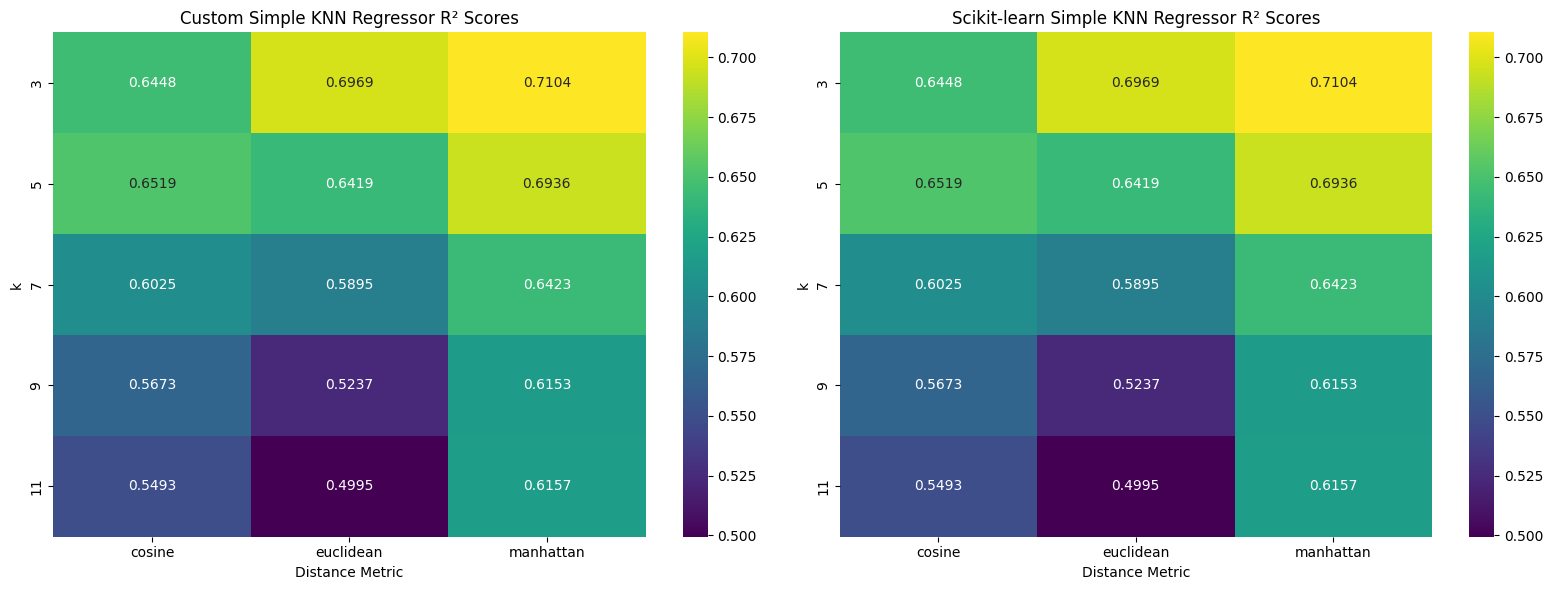

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Simple Regressor model plots for both custom and scikit learn

simple_pivot = results_df.pivot(index='k', columns='distance_metric', values='r2_score')
skl_simple_pivot = skl_results_df.pivot(index='k', columns='distance_metric', values='r2_score')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(simple_pivot, annot=True, cmap='viridis', fmt=".4f", ax=axes[0])
axes[0].set_title('Custom Simple KNN Regressor R² Scores')
axes[0].set_xlabel('Distance Metric')
axes[0].set_ylabel('k')

sns.heatmap(skl_simple_pivot, annot=True, cmap='viridis', fmt=".4f", ax=axes[1])
axes[1].set_title('Scikit-learn Simple KNN Regressor R² Scores')
axes[1].set_xlabel('Distance Metric')
axes[1].set_ylabel('k')

plt.tight_layout()
plt.show()

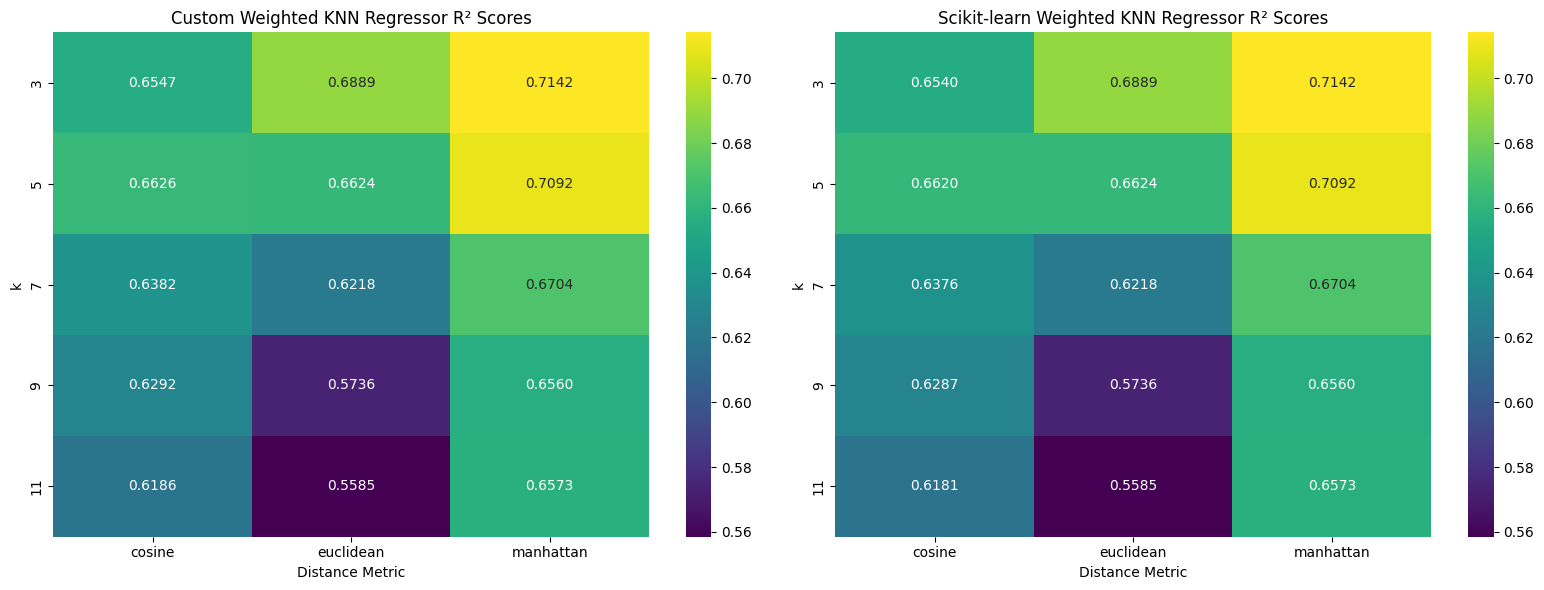

In [ ]:
# Weighted KNN plots for both custom and scikit_learn models

weighted_pivot = weighted_results_df.pivot(index='k', columns='distance_metric', values='r2_score')
skl_weighted_pivot = skl_weighted_results_df.pivot(index='k', columns='distance_metric', values='r2_score')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(weighted_pivot, annot=True, cmap='viridis', fmt=".4f", ax=axes[0])
axes[0].set_title('Custom Weighted KNN Regressor R² Scores')
axes[0].set_xlabel('Distance Metric')
axes[0].set_ylabel('k')

sns.heatmap(skl_weighted_pivot, annot=True, cmap='viridis', fmt=".4f", ax=axes[1])
axes[1].set_title('Scikit-learn Weighted KNN Regressor R² Scores')
axes[1].set_xlabel('Distance Metric')
axes[1].set_ylabel('k')

plt.tight_layout()
plt.show()

In [ ]:
# Comparing the R² scores of scikit-learn weighted KNN with our custom weighted KNN for the best combination.
best_weighted_custom_r2 = weighted_results_df[(weighted_results_df['k'] == best_weighted_k) & (weighted_results_df['distance_metric'] == best_weighted_metric)]['r2_score'].iloc[0]
best_weighted_skl_r2 = skl_weighted_results_df[(skl_weighted_results_df['k'] == best_weighted_k) & (skl_weighted_results_df['distance_metric'] == best_weighted_metric)]['r2_score'].iloc[0]

print(f"Custom Weighted KNN R² score for best combination (k={best_weighted_k}, metric='{best_weighted_metric}'): {best_weighted_custom_r2:.4f}")
print(f"Scikit-learn Weighted KNN R² score for best combination (k={best_weighted_k}, metric='{best_weighted_metric}'): {best_weighted_skl_r2:.4f}")

if abs(best_weighted_custom_r2 - best_weighted_skl_r2) < 1e-6:
    print("\nThe R² scores of the custom weighted and scikit-learn weighted models for the best combination are very similar.")
else:
    print("\nThe R² scores of the custom weighted and scikit-learn weighted models for the best combination are different.")

Custom Weighted KNN R² score for best combination (k=3, metric='manhattan'): 0.7142
Scikit-learn Weighted KNN R² score for best combination (k=3, metric='manhattan'): 0.7142

The R² scores of the custom weighted and scikit-learn weighted models for the best combination are very similar.


In [25]:
# Custom Simple KNN
custom_simple_model = KNNRegressor(k=best_k, distance_metric=best_metric)
custom_simple_model.fit(X_train, y_train)
custom_simple_predictions = custom_simple_model.predict(X_test)

# Scikit-learn Simple KNN
skl_simple_model = KNeighborsRegressor(n_neighbors=best_k, metric=best_metric, algorithm='brute', weights='uniform')
skl_simple_model.fit(X_train, y_train)
skl_simple_predictions = skl_simple_model.predict(X_test)

In [26]:
# Custom Weighted KNN
custom_weighted_model = WeightedKNNRegressor(k=best_weighted_k, distance_metric=best_weighted_metric)
custom_weighted_model.fit(X_train, y_train)
custom_weighted_predictions = custom_weighted_model.predict(X_test)

# Scikit-learn Weighted KNN
skl_weighted_model = KNeighborsRegressor(n_neighbors=best_weighted_k, metric=best_weighted_metric, algorithm='brute', weights='distance')
skl_weighted_model.fit(X_train, y_train)
skl_weighted_predictions = skl_weighted_model.predict(X_test)

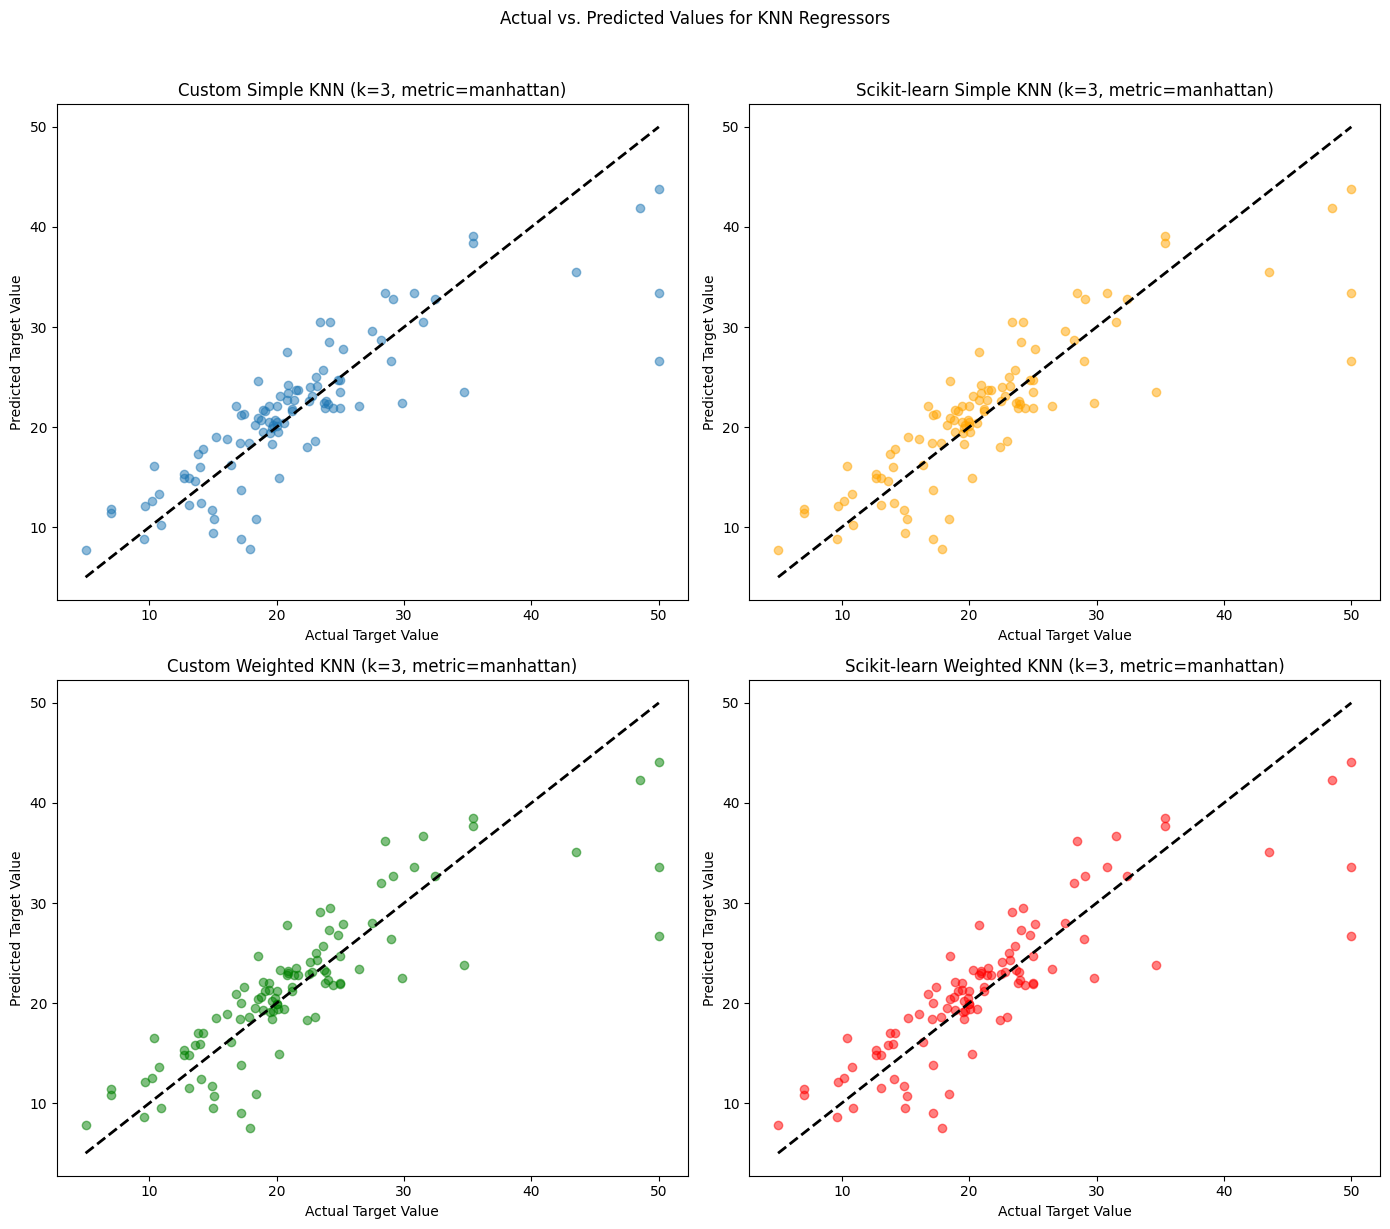

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('Actual vs. Predicted Values for KNN Regressors', y=1.02)

# Custom Simple KNN
axes[0, 0].scatter(y_test, custom_simple_predictions, alpha=0.5)
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
axes[0, 0].set_xlabel('Actual Target Value')
axes[0, 0].set_ylabel('Predicted Target Value')
axes[0, 0].set_title(f'Custom Simple KNN (k={best_k}, metric={best_metric})')

# Scikit-learn Simple KNN
axes[0, 1].scatter(y_test, skl_simple_predictions, alpha=0.5, color='orange')
axes[0, 1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
axes[0, 1].set_xlabel('Actual Target Value')
axes[0, 1].set_ylabel('Predicted Target Value')
axes[0, 1].set_title(f'Scikit-learn Simple KNN (k={best_k}, metric={best_metric})')

# Custom Weighted KNN
axes[1, 0].scatter(y_test, custom_weighted_predictions, alpha=0.5, color='green')
axes[1, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
axes[1, 0].set_xlabel('Actual Target Value')
axes[1, 0].set_ylabel('Predicted Target Value')
axes[1, 0].set_title(f'Custom Weighted KNN (k={best_weighted_k}, metric={best_weighted_metric})')

# Scikit-learn Weighted KNN
axes[1, 1].scatter(y_test, skl_weighted_predictions, alpha=0.5, color='red')
axes[1, 1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
axes[1, 1].set_xlabel('Actual Target Value')
axes[1, 1].set_ylabel('Predicted Target Value')
axes[1, 1].set_title(f'Scikit-learn Weighted KNN (k={best_weighted_k}, metric={best_weighted_metric})')

plt.tight_layout()
plt.show()

## Task 8: Summary

* For k=3 and distance = Manhattan, all four KNN Regressor models (custom simple, Scikit-learn simple, custom weighted, Scikit-learn Weighted) performed best.

* For the simple case, our implementation gives very close results when compared with scikit-learn's model. So is the case for the weighted model. In weighted model case, our implementation even outperformed scikit-learn's weighted model for some (k, distance metric) by a slight margin.

* Different distance metrics emphasize different relationships in the feature space. Euclidean captures global proximity, while cosine focuses on relative orientation — making it better suited for datasets where direction matters more than magnitude.

* Weighting schemes significantly influence prediction quality. Inverse distance weighting improves performance in datasets with high local variability by prioritizing closer neighbors.

* A slight modification to the weighting formula (e.g., adding epsilon or using Gaussian decay) can outperform built-in methods, especially in edge cases like near-zero distances.

* Empirically, manhattan distance combined with inverse weighting gave the best results for datasets with irregular spacing, while cosine distance performed best on normalized, directional data.

* "This work was assisted by AI tools for ideation and code generation, but the implementation and explanation are original."


